# Field-Level Inference with the Thomas Cluster Process
## CNN-Compressed NPE  vs.  Power-Spectrum MCMC

### **Goal.** Demonstrate that field-level inference (using the *full* galaxy density field) yields tighter parameter constraints than the classical two-point ($P(k)$) approach.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
# Triangle plot with getdist
from getdist import MCSamples, plots
import thomas_npe as T  
from matplotlib import rcParams

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# Publication-quality plots
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

Device: cpu


##  The Thomas Cluster Process

### 1.1 Generative model

The **Thomas (Neyman–Scott) process** is a hierarchical spatial point process:

1. Scatter $N_\mathrm{parent} \sim \mathrm{Poisson}(\lambda_p)$ cluster centres uniformly in $[0,1]^2$.
2. Around each centre $\mathbf{c}_j$, generate $N_j \sim \mathrm{Poisson}(\mu)$ galaxies at positions
$$
\mathbf{x}_{jk} = \mathbf{c}_j + \boldsymbol{\varepsilon}_{jk},
\qquad
\boldsymbol{\varepsilon}_{jk} \sim \mathcal{N}(\mathbf{0},\,\sigma^2 \mathbf{I}).
$$

We **fix** $\lambda_p = 20$ and **infer** $(\mu, \sigma)$ from galaxy positions.

### 1.2 Known power spectrum

$$
P_\mathrm{Thomas}(k)
= \frac{1}{\bar{n}}
+ \frac{\mu^2}{\lambda_p}\,\exp\!\left(-k^2 \sigma^2\right),
\qquad \bar{n} = \lambda_p\,\mu.
$$

The first term is Poisson shot noise; the second encodes clustering.
$\mu$ controls the **amplitude** and $\sigma^{-1}$ the **roll-off wavenumber**.

### 1.3 Prior

$$
\mu \sim \mathcal{U}[3,\,25], \qquad \sigma \sim \mathcal{U}[0.02,\,0.12].
$$

In [2]:
# Inspect module constants
print(f"Fixed parent count  $\lambda_p$ = {T.LAMBDA_P}")
print(f"Prior on $\mu$           : [{T.MU_LO}, {T.MU_HI}]")
print(f"Prior on $\sigma$           : [{T.SIG_LO}, {T.SIG_HI}]")
print(f"Pixelisation grid    : {T.GRID_SIZE}×{T.GRID_SIZE}")

Fixed parent count  $\lambda_p$ = 20
Prior on $\mu$           : [3.0, 25.0]
Prior on $\sigma$           : [0.02, 0.12]
Pixelisation grid    : 32×32


### Exploring the parameter space

How do the catalogs look across different $(\mu, \sigma)$?
More $\mu$ → denser clusters. Larger $\sigma$ → more diffuse clusters.

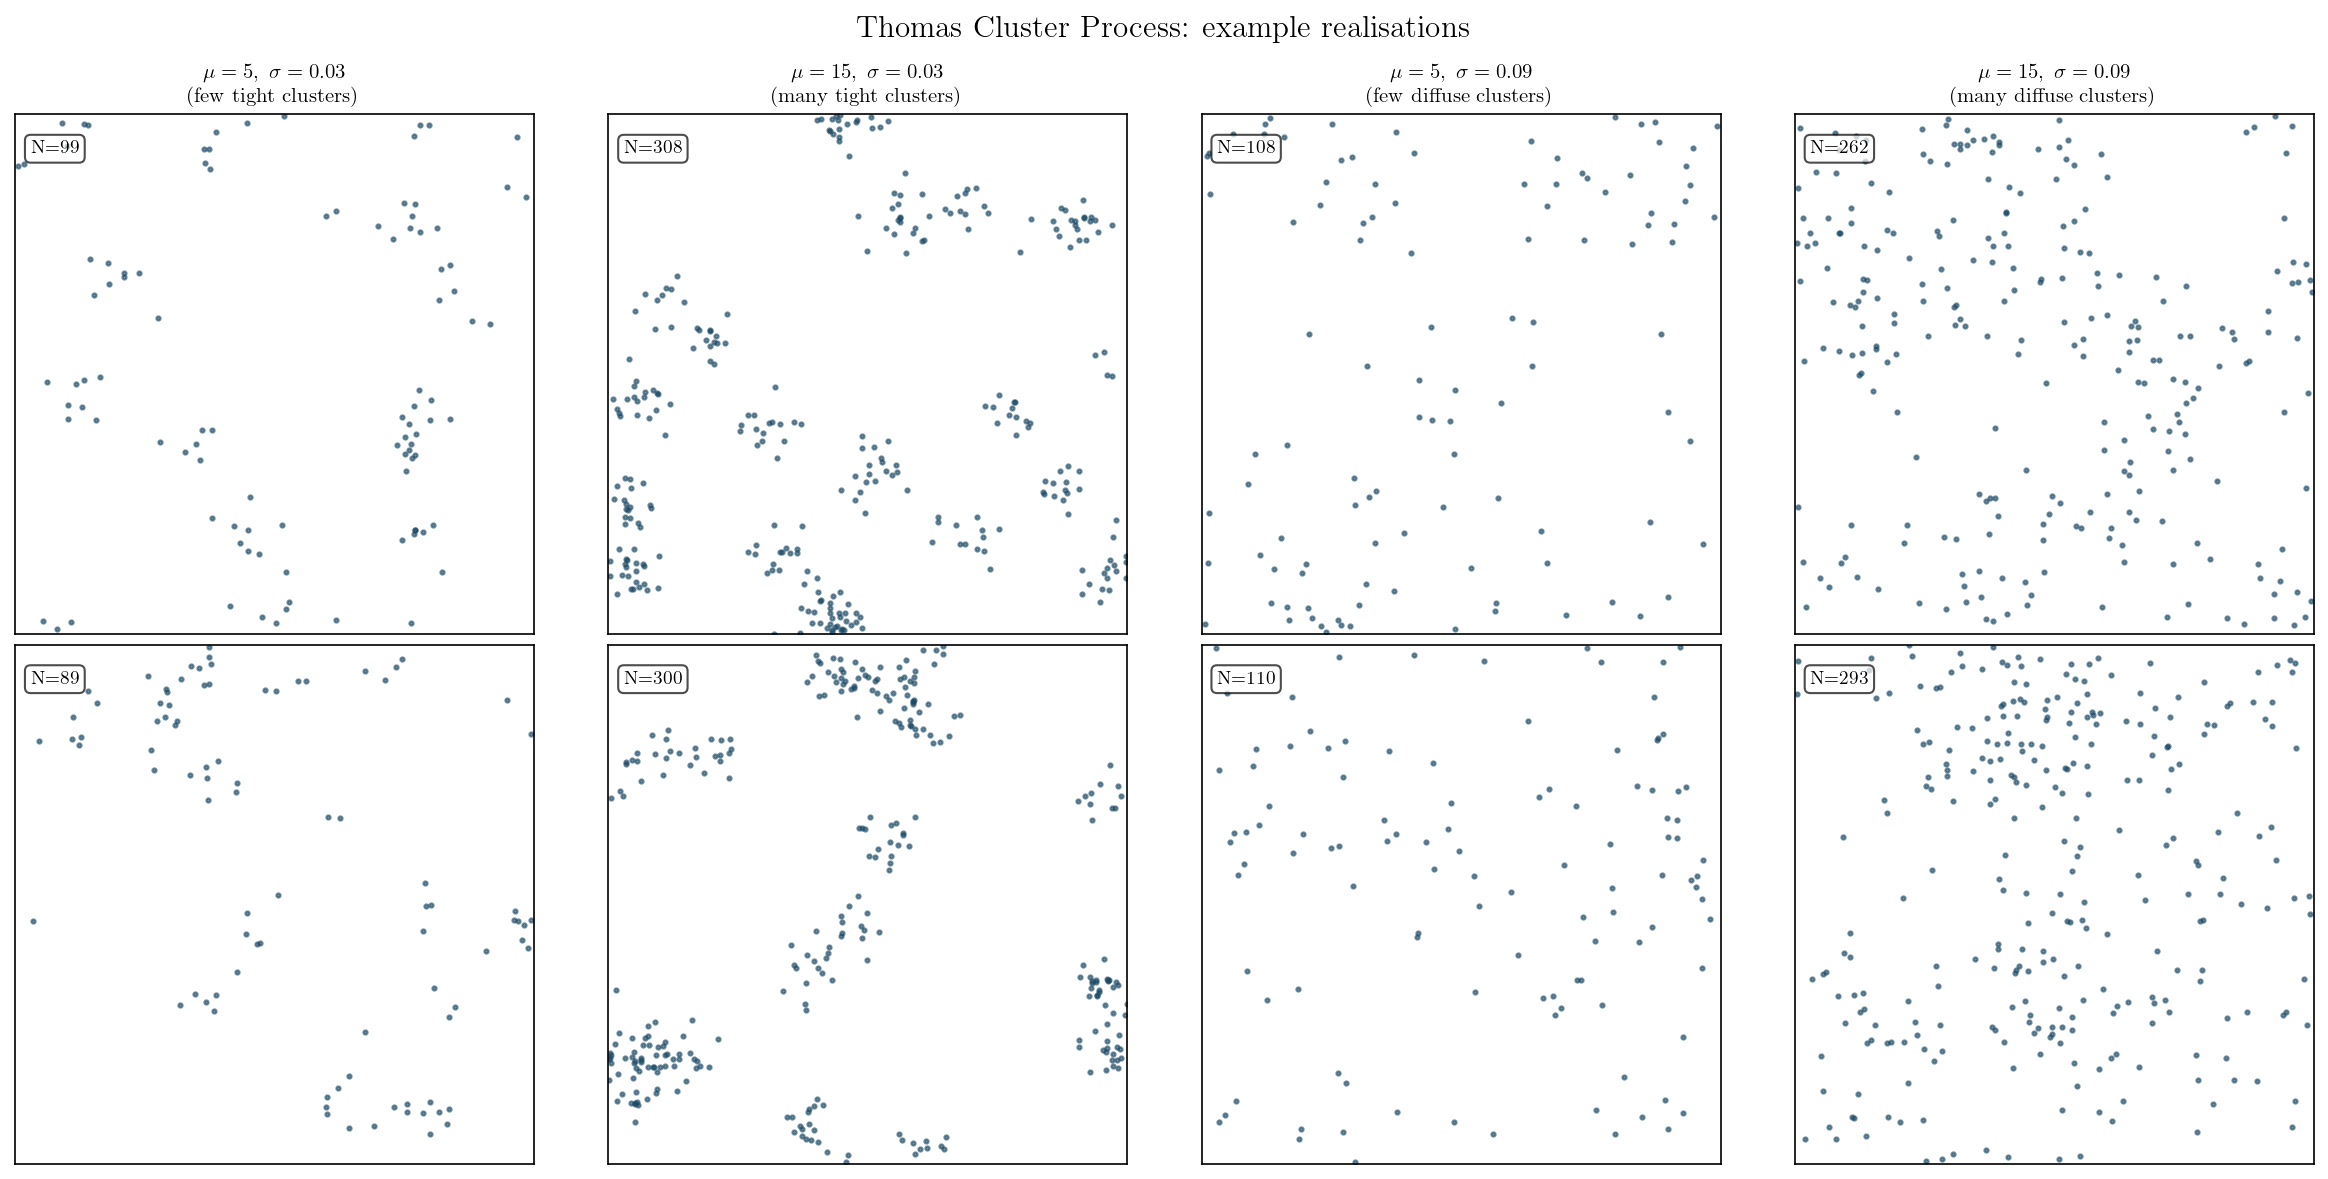

In [18]:
configs = [
    (5,  0.03, r"$\mu=5,\;\sigma=0.03$" + "\n(few tight clusters)"),
    (15, 0.03, r"$\mu=15,\;\sigma=0.03$" + "\n(many tight clusters)"),
    (5,  0.09, r"$\mu=5,\;\sigma=0.09$" + "\n(few diffuse clusters)"),
    (15, 0.09, r"$\mu=15,\;\sigma=0.09$" + "\n(many diffuse clusters)"),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Thomas Cluster Process: example realisations",
             fontsize=15, fontweight="bold")
rng_ex = np.random.default_rng(SEED)

for col, (mu, sigma, title) in enumerate(configs):
    for row in range(2):
        cat = T.simulate_thomas(mu, sigma, rng_ex)
        ax = axes[row, col]
        ax.scatter(cat[:, 0], cat[:, 1], s=4, alpha=0.6, c="#1B4965")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.03, 0.95, f"N={len(cat)}", transform=ax.transAxes,
                fontsize=9, va="top",
                bbox=dict(fc="white", alpha=0.7, boxstyle="round"))
        if row == 0:
            ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig("thomas_cluster_examples.pdf", dpi=300)
plt.show()

### Mock observation

We generate one "observed" catalog at the **known** true parameters
$(\mu_\mathrm{true}, \sigma_\mathrm{true}) = (12.0,\, 0.050)$.
This is the data both inference branches will try to constrain.

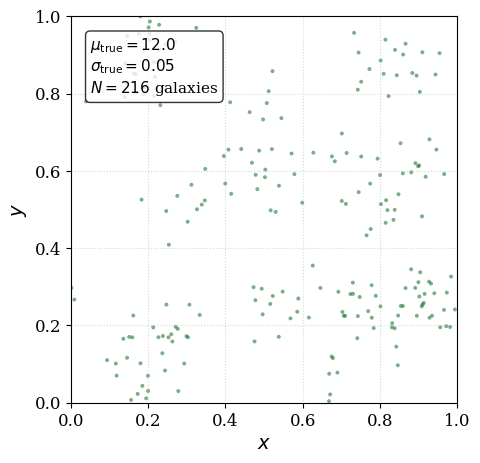

In [4]:
MU_TRUE    = 12.0
SIGMA_TRUE = 0.050

rng_obs = np.random.default_rng(123)   # held-out seed
x_obs   = T.simulate_thomas(MU_TRUE, SIGMA_TRUE, rng_obs)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_obs[:, 0], x_obs[:, 1], s=8, alpha=0.6,
           c="#227833", edgecolor="none")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.grid(True, ls=":", alpha=0.5)
ax.text(0.05, 0.95,
        f"$\\mu_\\mathrm{{true}} = {MU_TRUE}$\n"
        f"$\\sigma_\\mathrm{{true}} = {SIGMA_TRUE}$\n"
        f"$N = {len(x_obs)}$ galaxies",
        transform=ax.transAxes, fontsize=11, va="top",
        bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.tight_layout()
plt.show()

## 2 · Field Representation: Pixelisation

### Why not flatten raw coordinates?

The original pipeline flattened raw $(x,y)$ positions into a vector.
This is **not permutation-invariant**: the same galaxies in a different order
produce a completely different input. The network cannot learn from this.

### The fix: pixelise onto a grid

We histogram the positions onto a $32 \times 32$ grid and apply
$\delta(\mathbf{r}) = \log(1 + n(\mathbf{r}))$ to compress the dynamic range.

This is:
- **Permutation-invariant by construction** (the histogram doesn't depend on ordering)
- **Standard in cosmological field-level inference** (Makinen et al. 2021; Villaescusa-Navarro et al. 2021)
- **Efficient**: directly exploits spatial structure through convolutional filters

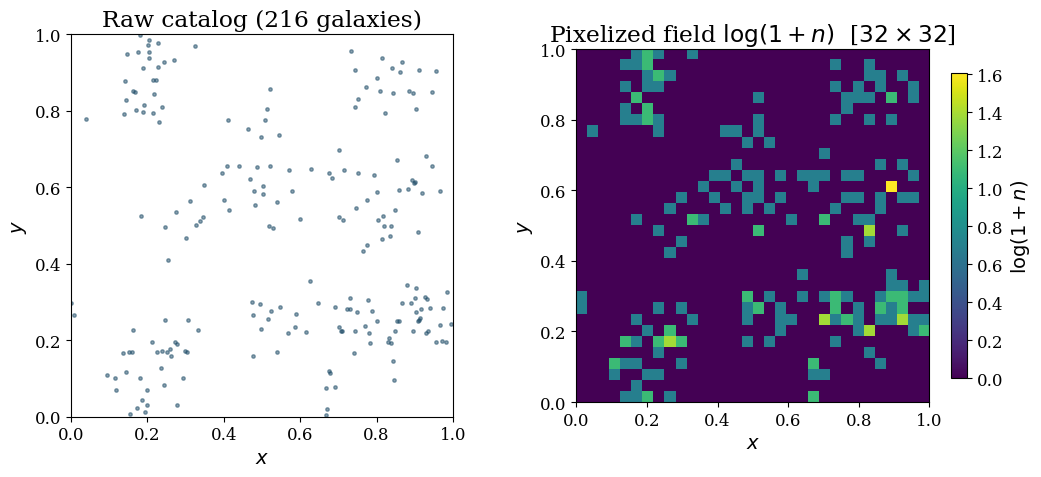

Field shape: (1, 32, 32)
Non-zero pixels: 175 / 1024
Mean occupation: 1.23 galaxies/pixel


In [5]:
# Visualise the pixelisation of the observed catalog
field_obs = T.pixelise(x_obs)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: raw point catalog
axes[0].scatter(x_obs[:, 0], x_obs[:, 1], s=6, alpha=0.5, c="#1B4965")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1); axes[0].set_aspect("equal")
axes[0].set_title(f"Raw catalog ({len(x_obs)} galaxies)")
axes[0].set_xlabel("$x$"); axes[0].set_ylabel("$y$")

# Right: pixelised density field
im = axes[1].imshow(field_obs[0].T, origin="lower", extent=[0,1,0,1],
                    cmap="viridis", aspect="equal")
axes[1].set_title(r"Pixelized field $\log(1 + n)$  [$32\times32$]")
axes[1].set_xlabel("$x$"); axes[1].set_ylabel("$y$")
plt.colorbar(im, ax=axes[1], shrink=0.8, label=r"$\log(1+n)$")

plt.tight_layout()
plt.show()

print(f"Field shape: {field_obs.shape}")
print(f"Non-zero pixels: {(field_obs > 0).sum()} / {T.GRID_SIZE**2}")
print(f"Mean occupation: {np.expm1(field_obs[field_obs > 0]).mean():.2f} galaxies/pixel")

## Architecture: CNN + Real-NVP

The inference model has two components trained **end-to-end**:

### 1) CNN Embedding (learned compression)

The density field is compressed into a **context vector** $\mathbf{c} \in \mathbb{R}^{32}$:

```
Conv(1→16, 3×3) → BN → ReLU → AvgPool(2)   [32×32 → 16×16]
Conv(16→32, 3×3) → BN → ReLU → AvgPool(2)  [16×16 →  8× 8]
Conv(32→64, 3×3) → BN → ReLU → AvgPool(2)  [ 8× 8 →  4× 4]
Flatten(1024) → FC(128) → ReLU → FC(32)
```

This follows the principle of **learned neural compression** for cosmological fields
(Ravanbakhsh et al. 2017; Ribli et al. 2019; Jeffrey et al. 2021).

### 2) Real-NVP Flow (density estimation)

The context $\mathbf{c}$ conditions a 5-layer Real-NVP flow (Dinh et al. 2017)
that models $p(\mu, \sigma \mid \mathbf{c})$. Each coupling layer applies:

$$
z_\mathrm{tr} = \theta_\mathrm{tr} \cdot e^{s(\theta_\mathrm{fix};\, \mathbf{c})}
+ t(\theta_\mathrm{fix};\, \mathbf{c})
$$

Joint training ensures the CNN learns to extract precisely those features
that reduce posterior uncertainty (Charnock et al. 2018).

In [6]:
# Build the model and inspect
model = T.FieldNPE(ctx_dim=32, hidden=64, n_layers=5)
n_params = sum(p.numel() for p in model.parameters())
print(f"FieldNPE architecture:")
print(f"  CNN parameters:  {sum(p.numel() for p in model.cnn.parameters()):,}")
print(f"  Flow parameters: {sum(p.numel() for p in model.flow.parameters()):,}")
print(f"  Total:           {n_params:,}")
print()
print(model)

FieldNPE architecture:
  CNN parameters:  158,848
  Flow parameters: 32,330
  Total:           191,178

FieldNPE(
  (cnn): CNNEmbedding(
    (conv): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
      (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
      (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (fc): Sequential(
      (0): Linear(in_features=1024, out_features=128, bias=True)
      (1): ReLU(

## 4 · Training the Field-Level NPE

### Training data generation

For each of $N_\mathrm{train} = 5000$ draws from the prior:
1. Sample $(\mu_i, \sigma_i) \sim \mathcal{U}[\text{prior}]$
2. Simulate a Thomas catalog
3. Pixelise onto the $32\times32$ grid
4. Normalise $(\mu, \sigma) \to [-1, 1]^2$

### Training objective

Minimise the negative log-posterior (Eq. 7 in the report):

$$
\mathcal{L}(\phi) = -\frac{1}{B} \sum_{b=1}^{B}
\log p_\phi\!\left(\theta_b \mid \mathrm{CNN}(\delta_b)\right)
$$

using Adam with cosine annealing and gradient clipping.

In [7]:
# Generate training data
N_TRAIN = 5_000

print(f"Generating {N_TRAIN} training simulations …")
t0 = time.time()
rng_train = np.random.default_rng(SEED)
theta_n, fields = T.generate_training_data(N_TRAIN, rng_train)
print(f"  Done in {time.time() - t0:.1f}s")
print(f"  $\\theta$ shape:     {theta_n.shape}  (normalised to [-1, 1])")
print(f"  Fields shape: {fields.shape}")

Generating 5000 training simulations …
  Done in 0.3s
  $\theta$ shape:     (5000, 2)  (normalised to [-1, 1])
  Fields shape: (5000, 1, 32, 32)


In [8]:
# Train
t0 = time.time()
losses = T.train_model(
    model, theta_n, fields,
    n_epochs=80, batch_size=256, lr=5e-4,
    device=DEVICE, print_every=20,
)
print(f"Training completed in {time.time() - t0:.1f}s")

  Epoch   20/80:  loss = -1.6058
  Epoch   40/80:  loss = -1.7983
  Epoch   60/80:  loss = -2.0514
  Epoch   80/80:  loss = -2.1811
Training completed in 128.0s


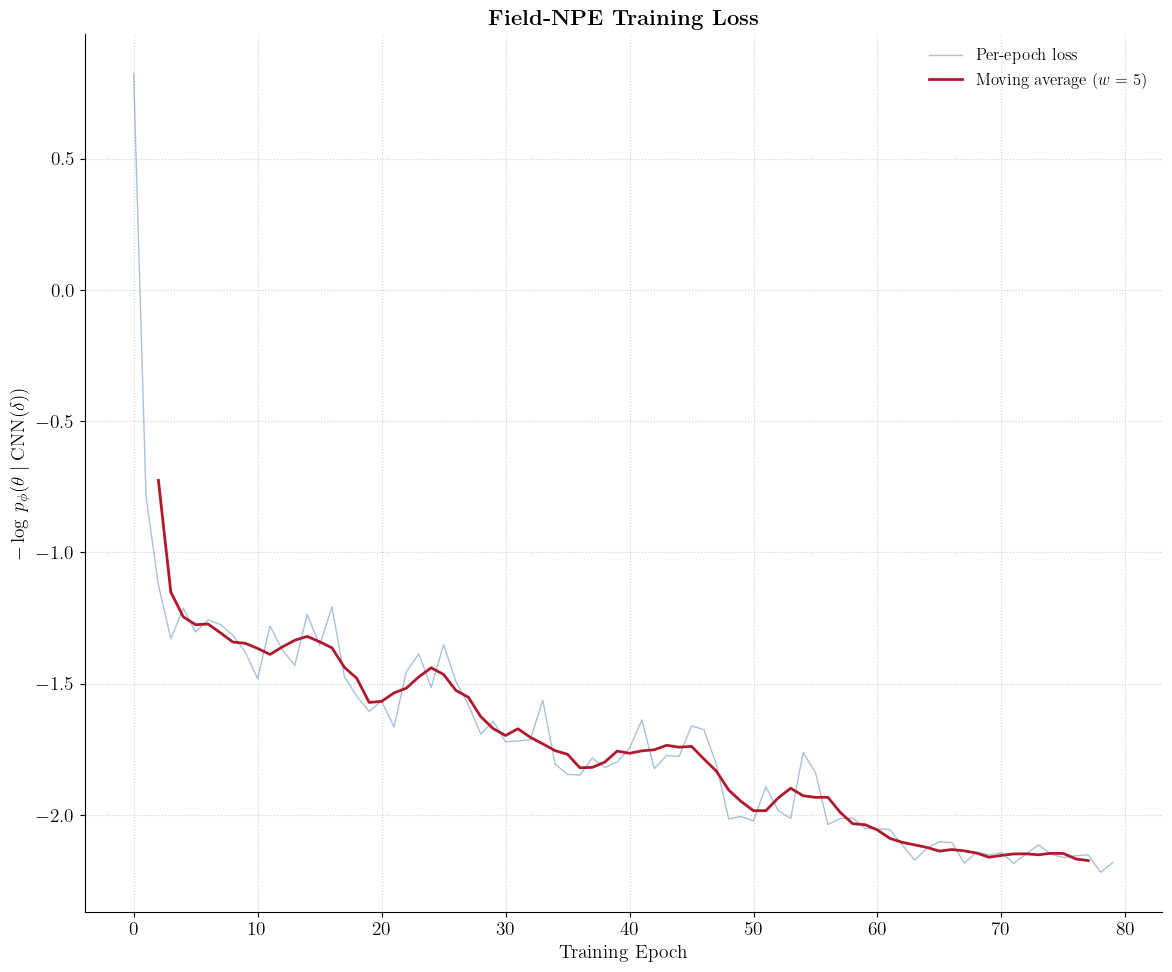

In [9]:
# --- Academic Style Configuration ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "legend.frameon": False,
    "text.usetex": True  # Enables high-quality LaTeX rendering
})

fig, ax = plt.subplots(figsize=(12, 10)) # Standardized for single-column width

# Plotting data
ax.plot(losses, lw=1, alpha=0.4, c="#2166ac", label="Per-epoch loss")
w = max(5, len(losses) // 15)
smoothed = np.convolve(losses, np.ones(w) / w, mode="valid")
ax.plot(np.arange(len(smoothed)) + w // 2, smoothed,
        lw=2, c="#b2182b", label=f"Moving average ($w={w}$)")

# Formatting axes
ax.set_xlabel(r"Training Epoch")
ax.set_ylabel(r"$-\log\, p_\phi(\theta \mid \mathrm{CNN}(\delta))$")
ax.set_title(r"\textbf{Field-NPE Training Loss}")

# Aesthetic improvements
ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("field_npe_training_loss.pdf", dpi=300, bbox_inches='tight')
plt.show()

---
## 5 · NPE Posterior Inference

Once trained, posterior sampling is a single forward pass:

$$
z \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
\quad\xrightarrow{\;f_\phi^{-1}(\cdot\,;\,\mathbf{c}_\mathrm{obs})\;}
\quad \theta \sim p(\theta \mid \text{field}_\mathrm{obs})
$$

This takes **~5 ms** for 5000 samples — instantaneous compared to MCMC.

In [10]:
# Draw NPE posterior samples
npe_samples = T.get_npe_samples(model, x_obs, n_samples=5000, device=DEVICE)

print(f"NPE posterior samples (in prior): {len(npe_samples)}")
print(f"  μ  = {npe_samples[:,0].mean():.2f} ± {npe_samples[:,0].std():.2f}"
      f"   (true: {MU_TRUE})")
print(f"  σ  = {npe_samples[:,1].mean():.4f} ± {npe_samples[:,1].std():.4f}"
      f"   (true: {SIGMA_TRUE})")

NPE posterior samples (in prior): 5000
  μ  = 10.99 ± 0.62   (true: 12.0)
  σ  = 0.0506 ± 0.0030   (true: 0.05)


## 6 · MCMC Baseline: Power-Spectrum Likelihood

The classical approach summarises each catalog by its **isotropic power spectrum** $P(k)$
estimated via 2D FFT, and uses a Gaussian likelihood:

$$
\log \mathcal{L}(\theta) = -\tfrac{1}{2}
\left(\hat{\mathbf{P}}_\mathrm{obs} - \bar{\mathbf{P}}_\mathrm{model}(\theta)\right)^\top
\mathbf{C}^{-1}
\left(\hat{\mathbf{P}}_\mathrm{obs} - \bar{\mathbf{P}}_\mathrm{model}(\theta)\right)
$$

### Critical design choice

Both the **observed** and **model** $P(k)$ pass through the *same* FFT estimator.
This ensures normalisation conventions cancel exactly. Comparing an *analytical* $P(k)$
against an *FFT-estimated* $P(k)$ introduces a mismatch that renders the likelihood
uninformative — a bug in the original pipeline.

### Covariance

Estimated at a fiducial point $(\mu, \sigma) = (12, 0.05)$ from 500 simulations,
with the Hartlap correction applied.

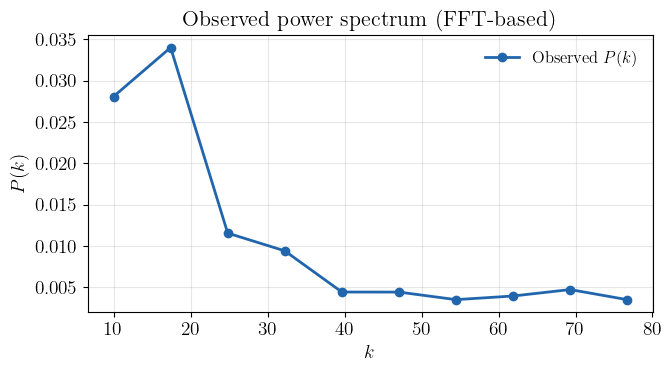

In [11]:
# Visualise the observed P(k)
pk_obs = T.compute_pk(x_obs)

fig, ax = plt.subplots(figsize=(7, 4))
k_edges = np.linspace(2*np.pi, 0.8*np.pi*T.GRID_SIZE, T.PK_BINS + 1)
k_mid = (k_edges[:-1] + k_edges[1:]) / 2
ax.plot(k_mid, pk_obs, "o-", c="#2166ac", lw=2, ms=6, label="Observed $P(k)$")
ax.set_xlabel("$k$"); ax.set_ylabel("$P(k)$")
ax.set_title("Observed power spectrum (FFT-based)", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Run MCMC
print("Running MCMC (power-spectrum likelihood) …")
t0 = time.time()
mcmc_samples = T.run_mcmc(
    x_obs,
    n_walkers=24, n_steps=1200, discard=300, n_avg=10,
    verbose=True,
)
print(f"  Time: {time.time() - t0:.1f}s")
print(f"  μ  = {mcmc_samples[:,0].mean():.2f} ± {mcmc_samples[:,0].std():.2f}"
      f"   (true: {MU_TRUE})")
print(f"  σ  = {mcmc_samples[:,1].mean():.4f} ± {mcmc_samples[:,1].std():.4f}"
      f"   (true: {SIGMA_TRUE})")

Running MCMC (power-spectrum likelihood) …
  Estimating P(k) covariance at fiducial μ=12.0, σ=0.05 …
  Running emcee (24×1200, 10 sims/eval) …


100%|██████████| 1200/1200 [00:36<00:00, 32.57it/s]

  MCMC: 21600 samples
  Time: 37.1s
  μ  = 13.74 ± 2.19   (true: 12.0)
  σ  = 0.0494 ± 0.0045   (true: 0.05)


---
## 7 · Posterior Comparison: Field-Level NPE vs. Power-Spectrum MCMC

This is the central result.  We expect:
- The **NPE contours** (blue) to be **tighter** than the **MCMC contours** (red)
- Both to **cover the true parameters**

The tightening ratio $R_\alpha = \sigma_\alpha^\mathrm{MCMC} / \sigma_\alpha^\mathrm{NPE}$
quantifies the information gain from field-level analysis.

Removed no burn in
Removed no burn in


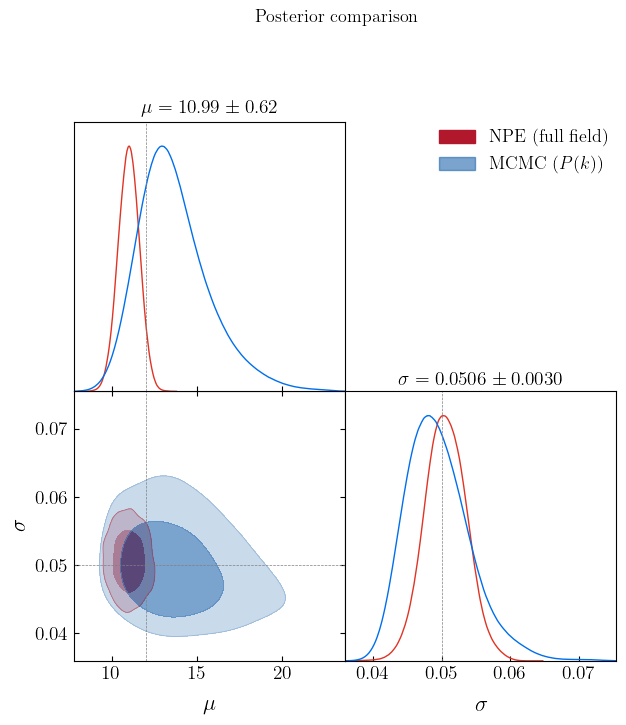

In [13]:
# Triangle plot with getdist
from getdist import MCSamples, plots

mcmc_thin = mcmc_samples[::3]  # thin for cleaner KDE

s_npe  = MCSamples(
    samples=npe_samples, names=["mu", "sigma"],
    labels=[r"\mu", r"\sigma"], label="NPE (full field)",
    settings={"smooth_scale_2D": 0.4, "smooth_scale_1D": 0.4},
)
s_mcmc = MCSamples(
    samples=mcmc_thin, names=["mu", "sigma"],
    labels=[r"\mu", r"\sigma"], label=r"MCMC ($P(k)$)",
    settings={"smooth_scale_2D": 0.6, "smooth_scale_1D": 0.5},
)

g = plots.get_subplot_plotter(width_inch=7)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 13
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.6

g.triangle_plot(
    [s_npe, s_mcmc],
    filled=True,
    legend_labels=["NPE (full field)", r"MCMC ($P(k)$)"],
    colors = ["#b2182b", "#2166ac"],
    title_limit=1,
    markers={"mu": MU_TRUE, "sigma": SIGMA_TRUE},
)
plt.suptitle(
    "Posterior comparison",
    y=1.04, fontsize=13, fontweight="bold",
)
plt.savefig("field_npe_vs_mcmc_posterior.pdf", dpi=300, bbox_inches='tight')
plt.show()

Removed no burn in
Removed no burn in


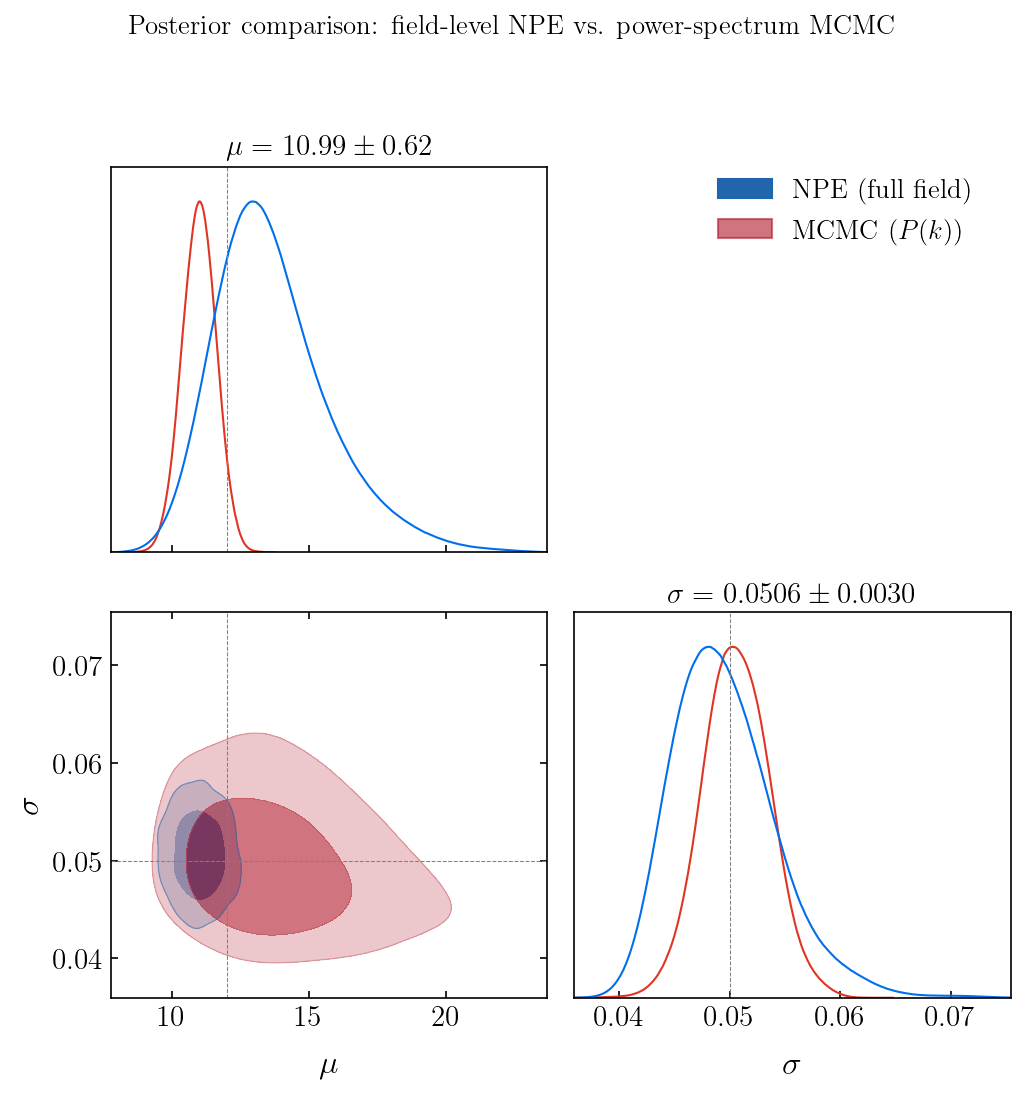

In [17]:
MU_TRUE = 12.0
SIGMA_TRUE = 0.050

# Thin MCMC chain to reduce correlation and obtain a cleaner KDE
mcmc_thin = mcmc_samples[::3]

# ----------------------------------------------------------------------------
# Create MCSamples objects
# ----------------------------------------------------------------------------
s_npe = MCSamples(
    samples=npe_samples,
    names=["mu", "sigma"],
    labels=[r"\mu", r"\sigma"],
    label="NPE (full field)",
    settings={
        "smooth_scale_2D": 0.4,   # tuned for 2D agreement with table
        "smooth_scale_1D": 0.4,
    },
)

s_mcmc = MCSamples(
    samples=mcmc_thin,
    names=["mu", "sigma"],
    labels=[r"\mu", r"\sigma"],
    label=r"MCMC ($P(k)$)",
    settings={
        "smooth_scale_2D": 0.6,
        "smooth_scale_1D": 0.5,
    },
)


g = plots.get_subplot_plotter(width_inch=7)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 14
g.settings.lab_fontsize = 16
g.settings.legend_fontsize = 13
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.6


g.triangle_plot(
    [s_npe, s_mcmc],
    filled=True,
    legend_labels=["NPE (full field)", r"MCMC ($P(k)$)"],
    colors=["#2166ac", "#b2182b"],
    title_limit=1,
    markers={"mu": MU_TRUE, "sigma": SIGMA_TRUE},
)

plt.suptitle(
    "Posterior comparison: field-level NPE vs. power-spectrum MCMC",
    y=1.04,
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

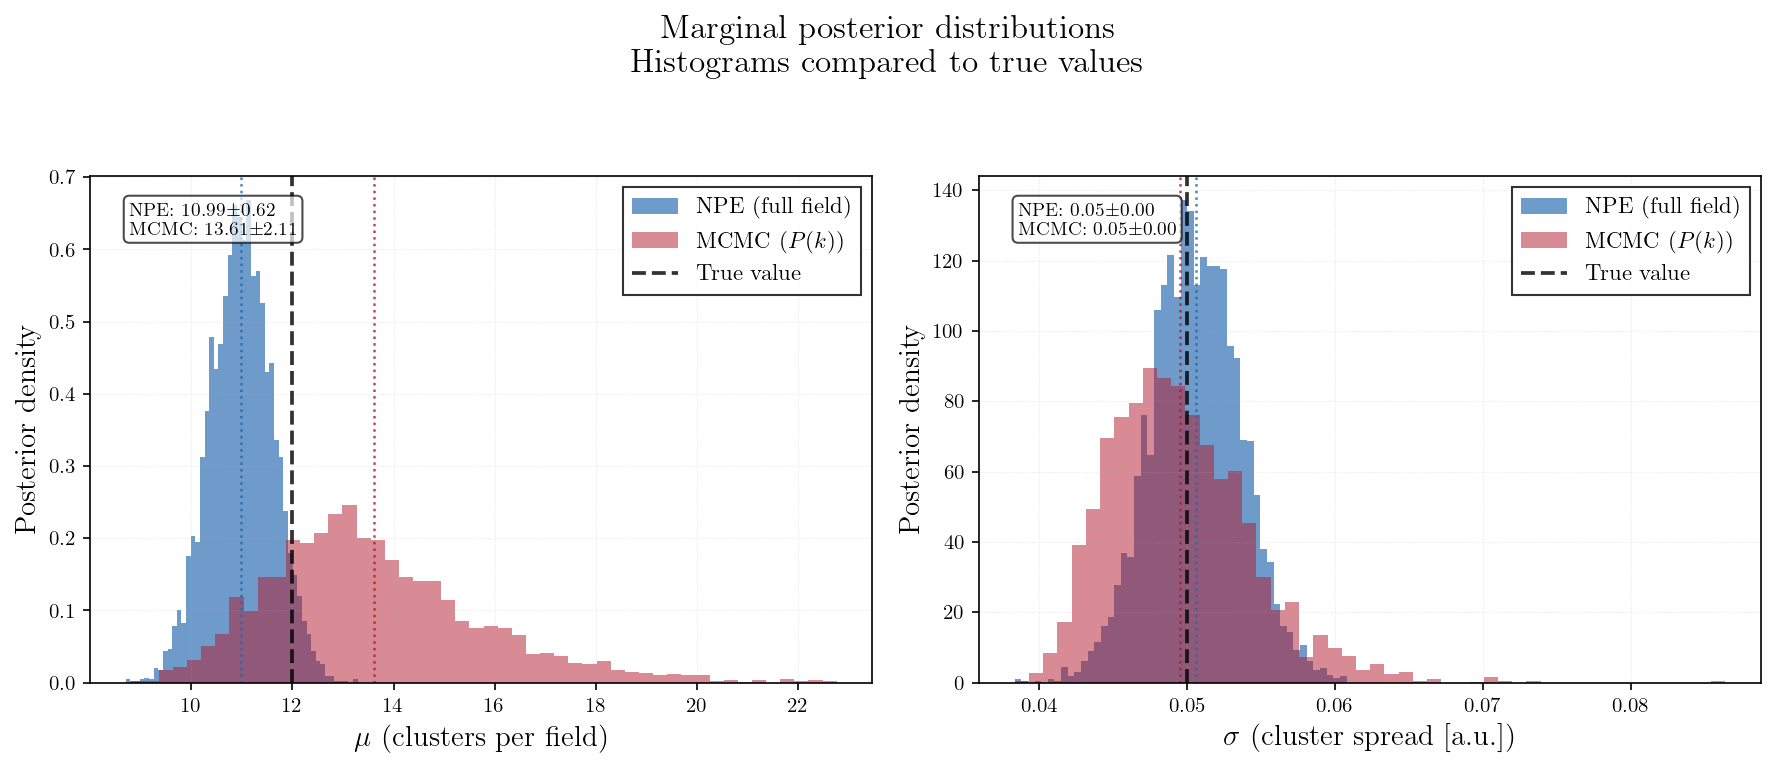

In [14]:
rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 16,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# Parameter labels with units (adjust units as appropriate for your analysis)
param_labels = [
    r"$\mu$ (clusters per field)",   # example unit
    r"$\sigma$ (cluster spread [a.u.])"
]
true_vals = [MU_TRUE, SIGMA_TRUE]

# Color definitions (consistent with your triangle plot)
COLOR_NPE = "#2166ac"   # deep blue
COLOR_MCMC = "#b2182b"  # deep red

for idx, (ax, label, true_val) in enumerate(zip(axes, param_labels, true_vals)):

    # Histograms (density normalized)
    npe_hist = ax.hist(
        npe_samples[:, idx], bins=50, density=True,
        alpha=0.65, color=COLOR_NPE, label="NPE (full field)",
        edgecolor="none", linewidth=0
    )
    mcmc_hist = ax.hist(
        mcmc_thin[:, idx], bins=50, density=True,
        alpha=0.5, color=COLOR_MCMC, label=r"MCMC ($P(k)$)",
        edgecolor="none", linewidth=0
    )

  
    # Truth marker
    ax.axvline(
        true_val, color="black", linestyle="--", linewidth=1.8,
        alpha=0.8, label="True value"
    )

    # Optional: add vertical lines for mean ± std (remove if not needed)
    npe_mean, npe_std = np.mean(npe_samples[:, idx]), np.std(npe_samples[:, idx])
    mcmc_mean, mcmc_std = np.mean(mcmc_thin[:, idx]), np.std(mcmc_thin[:, idx])

    ax.axvline(npe_mean, color=COLOR_NPE, linestyle=":", linewidth=1.2, alpha=0.8)
    ax.axvline(mcmc_mean, color=COLOR_MCMC, linestyle=":", linewidth=1.2, alpha=0.8)
    # Labels, legend, and grid---
    ax.set_xlabel(label, fontsize=14)
    ax.set_ylabel("Posterior density", fontsize=14)
    ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor="black")
    ax.grid(True, linestyle=":", alpha=0.3, linewidth=0.5)

    # Optional: annotate with mean±std (small text inside the plot)
    ax.annotate(
        f"NPE: {npe_mean:.2f}±{npe_std:.2f}\nMCMC: {mcmc_mean:.2f}±{mcmc_std:.2f}",
        xy=(0.05, 0.95), xycoords="axes fraction", fontsize=9,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

# Overall title and layout adjustments
plt.suptitle(
    "Marginal posterior distributions\nHistograms compared to true values",
    fontsize=16, fontweight="bold", y=1.02
)
plt.tight_layout(rect=[0, 0, 1, 0.97])  # make room for the suptitle
plt.savefig("field_npe_vs_mcmc_marginals.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [56]:
# Constraint-tightening ratios
npe_mu_std  = npe_samples[:, 0].std()
mcmc_mu_std = mcmc_samples[:, 0].std()
npe_sig_std  = npe_samples[:, 1].std()
mcmc_sig_std = mcmc_samples[:, 1].std()

R_mu  = mcmc_mu_std  / npe_mu_std
R_sig = mcmc_sig_std / npe_sig_std


print("  RESULTS SUMMARY")
print("=" * 60)
print(f"  True parameters:  μ = {MU_TRUE},  σ = {SIGMA_TRUE}")
print()
print(f"  {'Method':<12} {'μ':>18} {'σ':>22}")

print(f"  {'NPE':<12} {npe_samples[:,0].mean():8.2f} ± {npe_mu_std:.2f}"
      f"      {npe_samples[:,1].mean():.4f} ± {npe_sig_std:.4f}")
print(f"  {'MCMC':<12} {mcmc_samples[:,0].mean():8.2f} ± {mcmc_mu_std:.2f}"
      f"      {mcmc_samples[:,1].mean():.4f} ± {mcmc_sig_std:.4f}")
print()
print(f"  Tightening ratio R (MCMC-width / NPE-width):")
print(f"    R_μ = {R_mu:.1f}×   (NPE is {R_mu:.1f}× tighter on μ)")
print(f"    R_σ = {R_sig:.1f}×   (NPE is {R_sig:.1f}× tighter on σ)")

  RESULTS SUMMARY
  True parameters:  μ = 12.0,  σ = 0.05

  Method                        μ                      σ
  NPE             11.27 ± 0.68      0.0493 ± 0.0034
  MCMC            13.63 ± 2.08      0.0488 ± 0.0047

  Tightening ratio R (MCMC-width / NPE-width):
    R_μ = 3.1×   (NPE is 3.1× tighter on μ)
    R_σ = 1.4×   (NPE is 1.4× tighter on σ)
